## 오버피팅 

### overfitting 

`–` 정의: 모형의 일반화 성능이 떨어지는 현상 

### 예제소개 

`-` 아래와 같은 자료가 있다고 하자. 

In [3]:
toeic=[400,500,750,800,900,950]
gpa=[2.0,2.5,3.5,3.2,3.9,4.3]
y=[0,0,0,1,1,1]

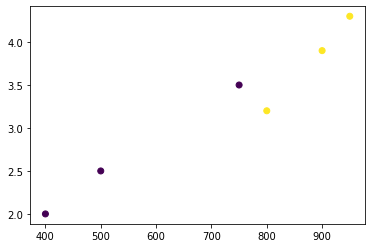

In [5]:
import matplotlib.pyplot as plt 
plt.scatter(toeic,gpa,marker='o',c=y)

`-` 토익과 학점을 바탕으로 합격/불합격을 예측하는 모형을 만들고자 한다. 아래와 같은 모형을 생각하자.
 - (population) $y \approx v =f(u)=\frac{e^u}{1+e^u}, \quad u=\beta_0+\beta_1\times toeic +\beta_2\times gpa$
 - (sample) $y_i\approx v_i=f(u_i)=\frac{e^{u_i}}{1+e^{u_i}}, \quad u_i=\beta_0+\beta_1\times toeic_i +\beta_2 \times gpa_i$

토익과 학점이 비등하게 반영되도록 하려면 토익을 1/100정도로 나누고, 학점에 2정도를 곱하면 될 것 같다. 

즉 $\beta_1=\frac{1}{100}$, $\beta_2=2.00$ 와 같이 설정하면 적당한 것 같다. 

In [11]:
import tensorflow as tf 
import numpy as np
X=np.array([toeic,gpa]).T
w=np.array([1/100,2])
b=np.array(0)
u=X@w+b 

In [12]:
u

array([ 8. , 10. , 14.5, 14.4, 16.8, 18.1])

$u$에서 14.5정도를 빼면 될것 같다. ($\beta_0=-14.5$로 설정한다)

In [17]:
import tensorflow as tf 
import numpy as np
X=np.array([toeic,gpa]).T
w=np.array([1/100,2])
b=np.array(-14.5)
u=X@w+b 
v=np.array(tf.nn.sigmoid(u))

In [20]:
u,v

(array([-6.5, -4.5,  0. , -0.1,  2.3,  3.6]),
 array([0.00150118, 0.01098694, 0.5       , 0.47502081, 0.90887704,
        0.97340301]))

`–` 팁: 경계선 근처에서 $u\approx 0$이 되도록 하면 $v\approx 0.5$가 된다.
- 왜? $v=\frac{e^u}{1+e^u}=\frac{1}{1+1}=\frac{1}{2}$

`–` 이제 $u \approx 0$ 혹은 $v \approx 0.5$ 를 경계로 합격/불합격을 판단하면 된다. 

경계선을 그려보자. 

$u=0 \Longleftrightarrow 0 = toeic \times \frac{1}{100}+ gpa \times 2.00 - 14.5 \quad \cdots (\star)$

$(\star)$를 만족하는 $(toeic,gpa)$의 집합을 그리면 아래와 같다.

> Note: 그림을 위한 예비계산: $gpa=\frac{14.5-toeic\times \frac{1}{100}}{2}$

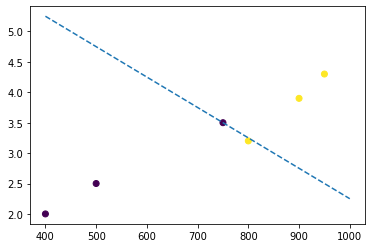

In [26]:
plt.scatter(toeic,gpa,marker='o',c=y)
_toeic = np.linspace(400,1000,1000)
_gpa=(14.5- _toeic/100)/2 #_gpa=(-b- _toeic*w[0])/w[1]
plt.plot(_toeic,_gpa,'--')

`–` 위의 그림처럼 $(toeic, gpa)$ 그림도 훌륭하지만.... 

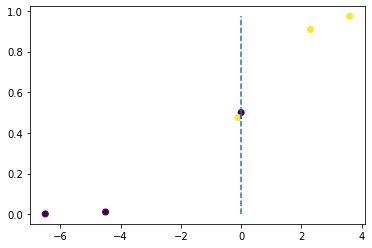

In [28]:
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')

사실상 toeic, gpa 2개의 변수가 $u$라는 하나의 변수에 압축되어서 신경망의 입력으로 들어가는 형태이다. 

신경망은 $0$을 기준으로 $u$가 큰 음수이면 $0$에 가까운 출력이 나오고 큰 양수이면 1에 가까운 출력을 준다. 

따라서 $u$의 값의 음수인지 양수인지 따져서 합격/불합격을 판단할 수 있다. 

또는 $v$의 값을 따져서 합격/불합격을 판단할 수 있다. 

`-` 따라서 $u=0$을 기준점으로 잡을 수 있는 것처럼 $v=0.5$도 기준선으로 잡을수 있다. 

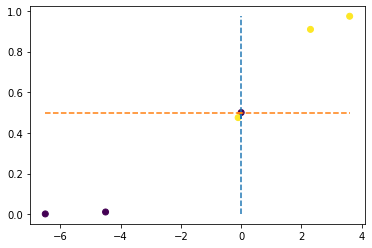

In [30]:
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.plot(u,v*0+0.5,'--')

`-` 정리를 해보자. 

`-` 모형
 - (population) $y \approx v =f(u)=\frac{e^u}{1+e^u}, \quad u=\beta_0+\beta_1\times toeic +\beta_2\times gpa$
 - (sample) $y_i\approx v_i=f(u_i)=\frac{e^{u_i}}{1+e^{u_i}}, \quad u_i=\beta_0+\beta_1\times toeic_i +\beta_2 \times gpa_i$

`-` (자료,계수값) $\to$ (그림)

In [40]:
toeic=[400,500,750,800,900,950]
gpa=[2.0,2.5,3.5,3.2,3.9,4.3]
y=[0,0,0,1,1,1]
X=np.array([toeic,gpa]).T
w=np.array([1/100,2])
b=np.array(-14.5)

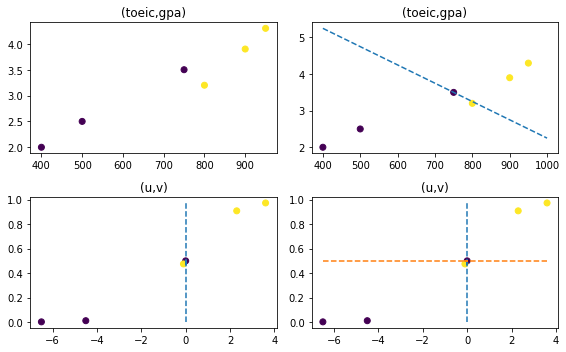

In [41]:
u=X@w+b 
v=np.array(tf.nn.sigmoid(u))
_toeic = np.linspace(400,1000,1000)
_gpa=(-b- _toeic*w[0])/w[1] #_gpa=(14.5- _toeic/100)/2 
plt.figure(figsize=(8,5))
plt.subplot(2,2,1)
plt.title("(toeic,gpa)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.subplot(2,2,2)
plt.title("(toeic,gpa)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.plot(_toeic,_gpa,'--')
plt.subplot(2,2,3)
plt.title("(u,v)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.subplot(2,2,4)
plt.title("(u,v)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.plot(u,v*0+0.5,'--')
plt.tight_layout()

`–` 계수값을 바꾸면서 결과를 확인하자. $\to$ GPA의 계수값을 상승시켜보자. 

In [48]:
toeic=[400,500,750,800,900,950]
gpa=[2.0,2.5,3.5,3.2,3.9,4.3]
y=[0,0,0,1,1,1]
X=np.array([toeic,gpa]).T
w=np.array([1/100,4])
b=np.array(-21)

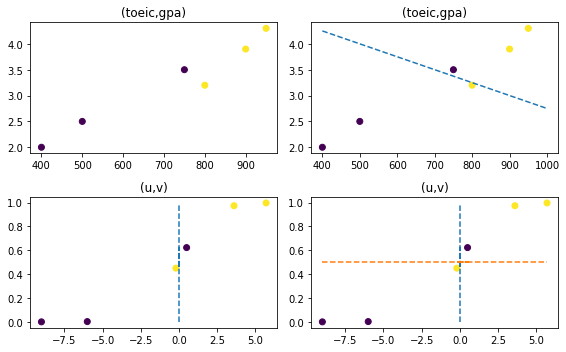

In [49]:
u=X@w+b 
v=np.array(tf.nn.sigmoid(u))
_toeic = np.linspace(400,1000,1000)
_gpa=(-b- _toeic*w[0])/w[1] #_gpa=(14.5- _toeic/100)/2 
plt.figure(figsize=(8,5))
plt.subplot(2,2,1)
plt.title("(toeic,gpa)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.subplot(2,2,2)
plt.title("(toeic,gpa)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.plot(_toeic,_gpa,'--')
plt.subplot(2,2,3)
plt.title("(u,v)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.subplot(2,2,4)
plt.title("(u,v)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.plot(u,v*0+0.5,'--')
plt.tight_layout()

`-` top-right의 그림에서 기울기가 평평해진다. $\to$ GPA값을 계속 키우면 극단적으로 $x$축에 평행한 수직선이 될것임. 
- $x$축에 평행한 수직선이라는 의미는 토익점수와 상관없이 GPA만 가지고 합격/불합격을 판단하는 구분자라는 의미 

### 잘못된 분석을 하는 사례1: $n$이 너무 적어서.. 

`-` 우상향직선을 잘 그으면 100% 분리를 쉽게 할 수 있을것 같다. 

In [61]:
toeic=[400,500,750,800,900,950]
gpa=[2.0,2.5,3.5,3.2,3.9,4.3]
y=[0,0,0,1,1,1]
X=np.array([toeic,gpa]).T
w=np.array([2/1000,-0.2])
b=np.array(-0.88)

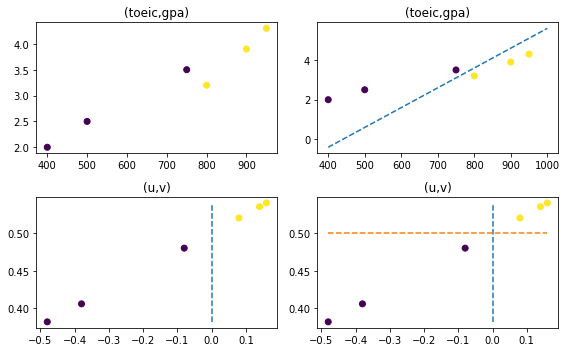

In [62]:
u=X@w+b 
v=np.array(tf.nn.sigmoid(u))
_toeic = np.linspace(400,1000,1000)
_gpa=(-b- _toeic*w[0])/w[1] #_gpa=(14.5- _toeic/100)/2 
plt.figure(figsize=(8,5))
plt.subplot(2,2,1)
plt.title("(toeic,gpa)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.subplot(2,2,2)
plt.title("(toeic,gpa)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.plot(_toeic,_gpa,'--')
plt.subplot(2,2,3)
plt.title("(u,v)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.subplot(2,2,4)
plt.title("(u,v)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.plot(u,v*0+0.5,'--')
plt.tight_layout()

`-` 모형 

$$y \approx v =f(u)=\frac{e^u}{1+e^u}, \quad u = -0.88 +\frac{2}{1000}\times toeic - 0.2 \times gpa $$ 

학점이 오를수록 $u$의 값은 작아지고, $f(u)$의 값은 0에 가까워진다. 

극단적으로 어떤사람의 학점이 500점이고, 토익 995라고 한다면 

In [63]:
-0.88 + 2/1000 * 995 - 0.2 *500 

-98.89

In [64]:
np.exp(-98.89)/(1+np.exp(-98.89))

1.1288043765777307e-43

합격확률은 0이다. 

`-` 쉽게 말해서 잘못된 모형이다. 

`-` 하지만 훈련 상황에서는 우수한 적중률을 보인 모형이었다. $\to$ 일반화성능이 약한모형, 과적합된 모형 

`-` 이러한 모형이 나온 원인? 데이터가 너무 적어서.. 

`-` 해결책? 데이터를 많이.. 

### 잘못된 분석을 하는 사례2: 너무 많은 $p$ 때문에.. 

딱봐도 첫번째 분석했던 모형이 더 현실과 맞아보인다. 

In [65]:
toeic=[400,500,750,800,900,950]
gpa=[2.0,2.5,3.5,3.2,3.9,4.3]
y=[0,0,0,1,1,1]
X=np.array([toeic,gpa]).T
w=np.array([1/100,2])
b=np.array(-14.5)

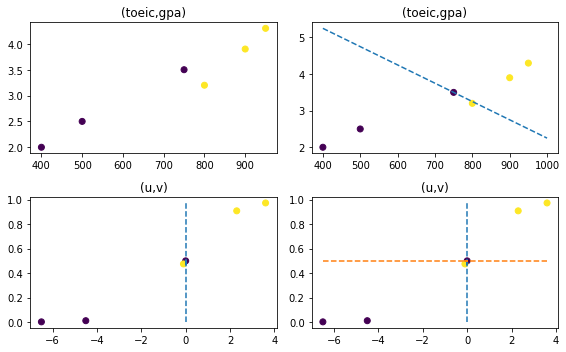

In [66]:
u=X@w+b 
v=np.array(tf.nn.sigmoid(u))
_toeic = np.linspace(400,1000,1000)
_gpa=(-b- _toeic*w[0])/w[1] #_gpa=(14.5- _toeic/100)/2 
plt.figure(figsize=(8,5))
plt.subplot(2,2,1)
plt.title("(toeic,gpa)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.subplot(2,2,2)
plt.title("(toeic,gpa)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.plot(_toeic,_gpa,'--')
plt.subplot(2,2,3)
plt.title("(u,v)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.subplot(2,2,4)
plt.title("(u,v)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.plot(u,v*0+0.5,'--')
plt.tight_layout()

욕심: 경계에 있는 값을 좀 더 잘 구분할 수 있을까? 

변수를 더 수집한다. (빅데이터? ㅋㅋㅋ)

In [67]:
toeic=[400,500,750,800,900,950]
gpa=[2.0,2.5,3.5,3.2,3.9,4.3]
boomuck=[1,0,1,0,1,0]
y=[0,0,0,1,1,1]

`–` 모형 

- $y \approx v =f(u)=\frac{e^u}{1+e^u}$
- $u = w_0 + toeic \times w_1 + gpa \times w_2 + boomuck\times w_3$

In [78]:
X=np.array([toeic,gpa,boomuck]).T
w=np.array([1/100,2,-2])
b=np.array(-12.5)

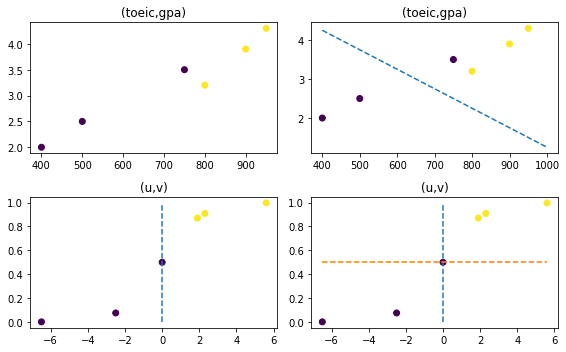

In [79]:
u=X@w+b 
v=np.array(tf.nn.sigmoid(u))
_toeic = np.linspace(400,1000,1000)
_gpa=(-b- _toeic*w[0])/w[1] #_gpa=(14.5- _toeic/100)/2 
plt.figure(figsize=(8,5))
plt.subplot(2,2,1)
plt.title("(toeic,gpa)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.subplot(2,2,2)
plt.title("(toeic,gpa)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.plot(_toeic,_gpa,'--')
plt.subplot(2,2,3)
plt.title("(u,v)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.subplot(2,2,4)
plt.title("(u,v)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.plot(u,v*0+0.5,'--')
plt.tight_layout()

구분될 수도 있을것 같다. 

`-` 극단적으로 부먹 vs 찍먹의 관측치가 `우연히` 아래와 같이 관측되었다면? 

In [80]:
toeic=[400,500,750,800,900,950]
gpa=[2.0,2.5,3.5,3.2,3.9,4.3]
boomuck=[0,0,0,1,0,0]
y=[0,0,0,1,1,1]

그러니까 (1) 일단 부어먹는 학생은 합격 (2) 찍어먹는 학생들은 토익-학점을 보고 합불판단 이런식으로 구분하면 된다. 

`-` 저런 데이터가 우연히 얻어졌다고 주장하는 것이 어거지 같은가?

밸런스게임을 무한반복해보자. 

- 민트초코 먹을 수 있음? 없음? 
- 평생 백수로 월 250 vs 평생 직장인 월 1억 
- 평생 양치안하기 vs 평생 샤워안하기 
- ... 

원하는 숫자만큼 변수를 만들 수 있다.  

이 변수를 다 넣고 적합을 시키면? $\to$ perfect fit 

`–` 쉽게 생각하면 $n$을 크게하면 문제가 해결될 것 같은데 그렇지 않다. 

모형을 안정화 시킬려면 밸런스 게임으로 부터 얻은 변수들이 사실 합격 불합격에 관계가 없다는 것을 보일려면 카테고리별로 (부먹/찍먹) 충분히 큰 숫자의 샘플을 확보해야한다. 

상황1: 밸런스게임의 변수가 1개일때: 탕수육을 부어먹든지 찍어먹든지 여부는 사실 합격 불합격 여부에 전혀 상관이 없다는 결론을 내라고싶다고 하자. 
- 증명방법: 
  - 부먹 100명, 찍먹 100명 확보 
  - 합격/불합격 관찰 $\to$ 각 카테고리에서 50:50 정도로 합불이 나누어짐. 
  - 결론: 부먹이든 찍먹이든 합격여부와는 무관 
- 한 200개 정도 샘플이 있으면 타당한 결론을 내릴 것 같다. 

상황2: 밸런스게임의 변수가 2개라고 하자.
 - 한 400개 정도의 샘플이 있어야 한다. 

상황3: 밸런스게임의 변수가 3개라고 하자.
 - 한 800개 정도의 샘플이 있어야 한다. 

상황4: 밸런스게임의 변수가 21개라고 하자.
 - 한 209715200개 정도의 샘플이 있어야 한다. 

In [81]:
100 * 2**21

209715200

요즘 관측하는 자료는 $p$의 숫자가 1000개정도는 가뿐히 넘어간다. 

MNIST 예제와 같이 `이미지 픽셀` $\to$ `숫자 예측`의 경우 변수의 숫자는 784개의 변수를 사용함.  

이 변수들이 각각 0과 1의 값만 가진다고 쳐도 $2^{784}$... 

***저주...***

> Note: 데이터의 차원이 늘어날수록 모형의 안정성을 위해서 더 많은 샘플이 필요해지고, 그래서 학습이 어려워지는 현상을 차원의 저주라고 한다. 

사례1, 사례2의 정리

사례1과 사례2는 결국 $n>>p$ 이어야 하는데 $n \approx p$이거나 $n<p$이기 때문에 생기는 문제라 볼 수 있다. 

학습이 제대로 되지 않는 상황은 $\beta_0,\beta_1,\beta_2,\dots,\beta_p$의 값을 엉뚱하게 추론하는 것인데 이러한 일이 생기는 원인을 회귀모형으로 다시돌아가 생각하면 자명하다. 

`-` $n<p$ 일때 

- $\beta_0,\beta_1,\beta_2$의 해석해는 $({\bf X}^\top {\bf X})^{-1}{\bf X}^\top {\bf y}$ 인데 $n<p$일 경우는 역행렬이 없으므로 해를 구할 수 없다. 
- 해석해로 구하지 않고 수치해석적인 방법으로 해를 구하면 숫자가 나오긴 하지만 그 숫자를 신뢰할 수 없다. 문제상황과 같이 $n<p$인 경우는 $\beta_0,\beta_1,\beta_2,\dots\beta_p$의 값을 적덩히 조정하여 쉽게 perfert fit을 만들수 있다. 그런데 한번 perfit fit이 발생하면 (그 값이 아무리 엉뚱한 계수값라고 할지라도, 즉 탕수육을 찍어먹으면 합격하더라는 엉뚱한 모형을 만드는 계수값이라 할지라도) 더 이상 업데이트가 일어나지 않는다.  (왜? perfit fit에서 loss가 0이므로) 

`-` $n\approx p$이거나, $n>>p$ 이 아닌 경우 

 - $n<p$ 일 경우와 동일 

그냥 충분한 숫자의 데이터를 모으면 해결이 될것 같지만? 그렇지도 않다. 

### 오버피팅을 피하기 위한 노력 

`-` 변수를 줄이자. 
 - 드랍아웃: 입력층이나 은닉충의 노드중 몇개를 임의로 제거

`-` 데이터를 늘리자. 
- 회전, 색깔변화등을 활용해서 이미지 자료를 증가시킴. 

`-` 규제화 
- $\lambda \|\beta\|_1$ 혹은 $\lambda \|\beta \|_2^2$ 규제화 사용 $\to$ 꼭 필요한 파라메터를 제외하고는 0을 만들거나 0에 가까운 숫자로 축소시킨다. 

`-` 전처리 
- 데이터를 학습하기 좋은 형태로 가공하여 전달. (차원축소, 공선성제거) 

`-` 앙상블 
- 여러모형을 합쳐서 평균을 낸다. 